# Multivariate Statistical Analysis of Premier League Player Statistics

**Course:** Multivariate Statistics  
**Dataset:** Premier League Player Statistics  
**Software:** Python / Jupyter Notebook  

This project analyzes player-level statistics from the English Premier League.  
The objective of this project is to apply the multivariate statistical methods studied during the course. The analysis includes exploratory visualization of the data, linear regression modeling, variable selection, principal component analysis (PCA), correlation analysis, and interpretation of the obtained statistical results.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.cluster import KMeans

import statsmodels.api as sm

## 1. Dataset Source and Loading

The dataset used in this project is the **Premier League 2024–2025 Data** dataset from Kaggle.

**Source:** https://www.kaggle.com/datasets/furkanark/premier-league-2024-2025-data?resource=download

The dataset contains player-level statistics from the English Premier League 2024–2025 season.  
It includes information about players, teams, positions, playing time, goals, assists, cards, and per-90-minute performance indicators.

According to the project requirements, the dataset must contain at least 100 observations and at least 5 quantitative variables. This dataset satisfies both conditions.

In [3]:
df = pd.read_csv("Squad_PlayerStats__stats_standard.csv")

df.head()

,Rk,Player,Nation,Pos,Squad,Age,Born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,...,Performance_PK,Performance_PKatt,Performance_CrdY,Performance_CrdR,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_G-PK,Per 90 Minutes_G+A-PK,Matches
0,1,Max Aarons,eng ENG,DF,Bournemouth,24.0,2000.0,3,1,86,...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,Matches
1,2,Joshua Acheampong,eng ENG,DF,Chelsea,18.0,2006.0,4,2,170,...,0,0,1,0,0.00,0.00,0.00,0.00,0.00,Matches
2,3,Tyler Adams,us USA,MF,Bournemouth,25.0,1999.0,28,21,1965,...,0,0,7,0,0.00,0.14,0.14,0.00,0.14,Matches
3,4,Tosin Adarabioyo,eng ENG,DF,Chelsea,26.0,1997.0,22,15,1409,...,0,0,4,0,0.06,0.06,0.13,0.06,0.13,Matches
4,5,Simon Adingra,ci CIV,MF,Brighton,22.0,2002.0,29,12,1097,...,0,0,0,0,0.16,0.16,0.33,0.16,0.33,Matches


## 2. Dataset Size and General Structure

Before starting the statistical analysis, we check the number of observations and variables in the dataset.

In [4]:
print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])

Number of observations: 574
Number of variables: 25


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 574 entries, 0 to 573
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Rk                     574 non-null    int64  
 1   Player                 574 non-null    str    
 2   Nation                 573 non-null    str    
 3   Pos                    574 non-null    str    
 4   Squad                  574 non-null    str    
 5   Age                    573 non-null    float64
 6   Born                   573 non-null    float64
 7   Playing Time_MP        574 non-null    int64  
 8   Playing Time_Starts    574 non-null    int64  
 9   Playing Time_Min       574 non-null    int64  
 10  Playing Time_90s       574 non-null    float64
 11  Performance_Gls        574 non-null    int64  
 12  Performance_Ast        574 non-null    int64  
 13  Performance_G+A        574 non-null    int64  
 14  Performance_G-PK       574 non-null    int64  
 15  Performance_PK   

## 3. Variables in the Dataset

The following output shows all variables included in the dataset.  
This helps us separate quantitative variables from categorical variables.

In [6]:
df.columns

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Age', 'Born',
       'Playing Time_MP', 'Playing Time_Starts', 'Playing Time_Min',
       'Playing Time_90s', 'Performance_Gls', 'Performance_Ast',
       'Performance_G+A', 'Performance_G-PK', 'Performance_PK',
       'Performance_PKatt', 'Performance_CrdY', 'Performance_CrdR',
       'Per 90 Minutes_Gls', 'Per 90 Minutes_Ast', 'Per 90 Minutes_G+A',
       'Per 90 Minutes_G-PK', 'Per 90 Minutes_G+A-PK', 'Matches'],
      dtype='str')

### Interpretation

The dataset contains 574 observations and 25 variables. The variables include both categorical and quantitative characteristics of Premier League players.

Categorical variables include:
- Player
- Nation
- Pos
- Squad

The remaining variables are numerical and describe player age, playing time, attacking performance, disciplinary records, and per-90-minute statistics.

Only a very small number of missing values are present. Specifically, the variables Age, Born, and Nation contain one missing observation each. Since the amount of missing data is negligible compared to the total sample size, it is not expected to significantly affect the analysis.

## 4. Missing Values Analysis

Before proceeding with the statistical analysis, we examine whether the dataset contains missing values.

In [7]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Nation    1
Age       1
Born      1
dtype: int64

### Interpretation

The missing values analysis reveals that only three variables contain missing observations: Nation, Age, and Born. Each of these variables contains exactly one missing value.

Since the dataset contains 574 observations, the proportion of missing data is extremely small (less than 0.2%). Therefore, the missing values are unlikely to have a significant impact on the statistical analysis.

For the subsequent analyses, observations containing missing values will be removed to ensure consistency of the results.

## 5. Selection of Quantitative Variables

The dataset contains both categorical and numerical variables. Since the methods used in this project (linear regression and principal component analysis) require numerical inputs, only quantitative variables are selected for further analysis.

In [8]:
quantitative_vars = [
    'Age',
    'Born',
    'Playing Time_MP',
    'Playing Time_Starts',
    'Playing Time_Min',
    'Playing Time_90s',
    'Performance_Gls',
    'Performance_Ast',
    'Performance_G+A',
    'Performance_G-PK',
    'Performance_PK',
    'Performance_PKatt',
    'Performance_CrdY',
    'Performance_CrdR',
    'Per 90 Minutes_Gls',
    'Per 90 Minutes_Ast',
    'Per 90 Minutes_G+A',
    'Per 90 Minutes_G-PK',
    'Per 90 Minutes_G+A-PK'
]

df_num = df[quantitative_vars].copy()

df_num.head()

,Age,Born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,Playing Time_90s,Performance_Gls,Performance_Ast,Performance_G+A,Performance_G-PK,Performance_PK,Performance_PKatt,Performance_CrdY,Performance_CrdR,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_G-PK,Per 90 Minutes_G+A-PK
0,24.0,2000.0,3,1,86,1.0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00
1,18.0,2006.0,4,2,170,1.9,0,0,0,0,0,0,1,0,0.00,0.00,0.00,0.00,0.00
2,25.0,1999.0,28,21,1965,21.8,0,3,3,0,0,0,7,0,0.00,0.14,0.14,0.00,0.14
3,26.0,1997.0,22,15,1409,15.7,1,1,2,1,0,0,4,0,0.06,0.06,0.13,0.06,0.13
4,22.0,2002.0,29,12,1097,12.2,2,2,4,2,0,0,0,0,0.16,0.16,0.33,0.16,0.33


In [9]:
df_num = df_num.dropna()

print("Shape after removing missing values:", df_num.shape)

Shape after removing missing values: (573, 19)


## 6. Descriptive Statistics

Descriptive statistics provide a summary of the central tendency and variability of the quantitative variables. These measures help us understand the overall characteristics of the dataset before applying multivariate statistical methods.

In [10]:
desc_stats = df_num.describe().T

desc_stats

,count,mean,std,min,25%,50%,75%,max
Age,573.0,25.047120,4.494699,15.0,22.0,25.00,28.00,39.00
Born,573.0,1998.575916,4.517245,1985.0,1996.0,1999.00,2002.00,2009.00
Playing Time_MP,573.0,20.184991,12.215031,1.0,9.0,21.00,32.00,38.00
Playing Time_Starts,573.0,14.589878,12.300195,0.0,3.0,12.00,25.00,38.00
Playing Time_Min,573.0,1310.520070,1053.148842,1.0,332.0,1106.00,2205.00,3420.00
Playing Time_90s,573.0,14.560733,11.701714,0.0,3.7,12.30,24.50,38.00
Performance_Gls,573.0,1.888307,3.540192,0.0,0.0,0.00,2.00,29.00
Performance_Ast,573.0,1.403141,2.254705,0.0,0.0,0.00,2.00,18.00
Performance_G+A,573.0,3.291449,5.221045,0.0,0.0,1.00,4.00,47.00
Performance_G-PK,573.0,1.767888,3.146240,0.0,0.0,0.00,2.00,20.00


### Interpretation

The descriptive statistics reveal substantial variability among Premier League players.

The average player age is approximately 25 years, with ages ranging from 15 to 39 years. The average player participated in about 20 matches and started approximately 15 matches during the season.

Offensive statistics show considerable heterogeneity. While many players recorded no goals or assists, some players achieved exceptionally high values. For example, the maximum number of goals is 29, the maximum number of assists is 18, and the maximum combined goals and assists is 47.

The large differences between the minimum and maximum values indicate that the dataset contains players with very different roles and performance levels.

# Exploratory Data Analysis

## 7. Distribution of Player Ages

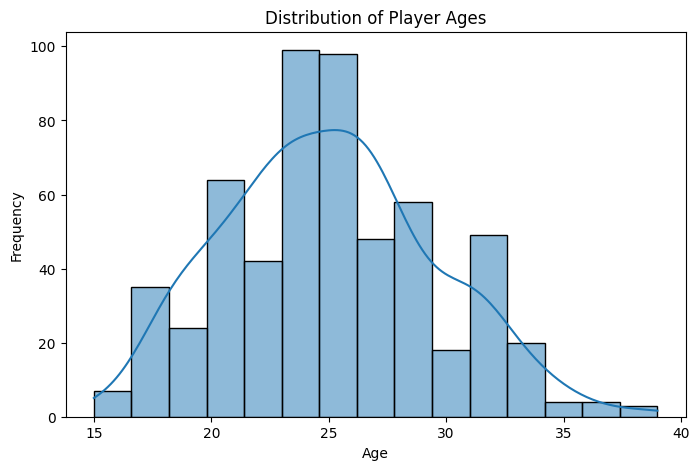

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df_num['Age'], bins=15, kde=True)

plt.title("Distribution of Player Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Interpretation

The age distribution of Premier League players appears approximately bell-shaped, with most players concentrated between 22 and 30 years of age. The highest frequency is observed around 24–26 years, suggesting that the typical Premier League player is in the middle of their athletic prime.

The distribution shows a slight right skew, with a relatively small number of older players above 33 years of age. Very young players (below 18 years) are also relatively rare.

Overall, the age distribution appears considerably closer to a Gaussian distribution than the performance-related variables analyzed later. This reflects the fact that professional football players tend to reach the highest level of competition within a relatively narrow age range.

## 8. Distribution of Playing Time

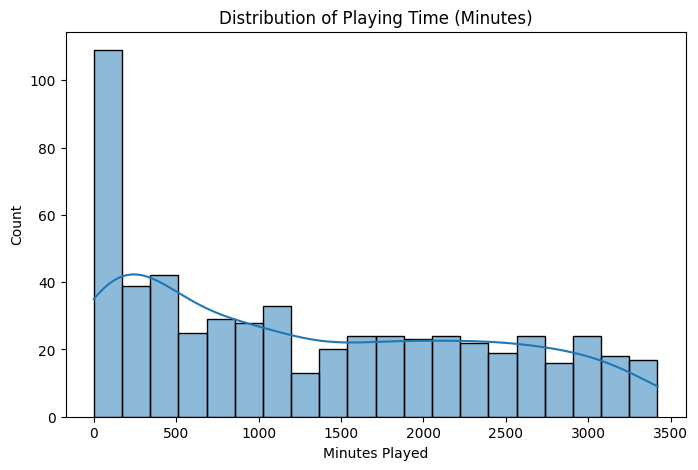

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df_num['Playing Time_Min'], bins=20, kde=True)

plt.title("Distribution of Playing Time (Minutes)")
plt.xlabel("Minutes Played")

plt.show()

### Interpretation

The distribution of playing time is strongly right-skewed and clearly differs from a Gaussian distribution.

A large number of players accumulated relatively few minutes during the season, while a smaller group of players participated regularly and accumulated more than 2500–3000 minutes. This pattern is expected in professional football because teams typically have a limited number of regular starters, whereas many players serve as substitutes or participate only occasionally.

The presence of a long right tail indicates substantial heterogeneity in playing time among players. Consequently, playing time appears to be one of the variables that may help explain differences in player performance in later regression analyses.

## 9. Distribution of Goals

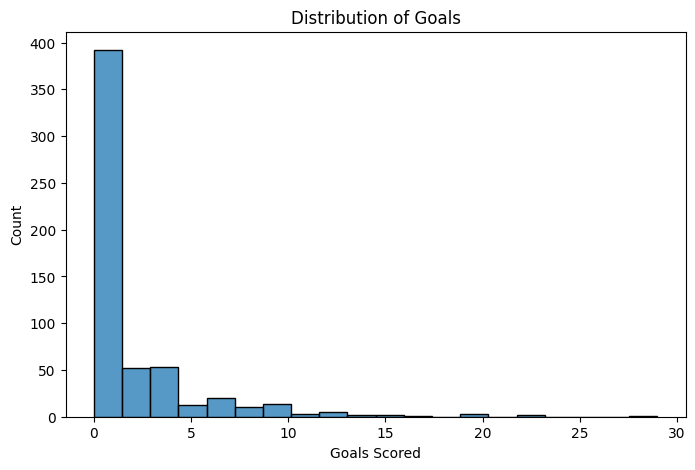

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df_num['Performance_Gls'], bins=20)

plt.title("Distribution of Goals")
plt.xlabel("Goals Scored")

plt.show()

### Interpretation

The distribution of goals scored is highly right-skewed and far from a Gaussian distribution.

Most players scored very few goals during the season, with a large concentration of observations at zero or near-zero values. In contrast, only a small number of players scored a large number of goals, creating a long right tail that extends to nearly 30 goals.

This pattern reflects the nature of football, where goal scoring is concentrated among a relatively small group of attacking players, while defenders, goalkeepers, and many midfielders score infrequently. The presence of extreme values and strong asymmetry indicates that the variable does not satisfy the assumptions of normality.

The distribution also suggests substantial heterogeneity in offensive performance among Premier League players.

## 10. Top Goal Scorers

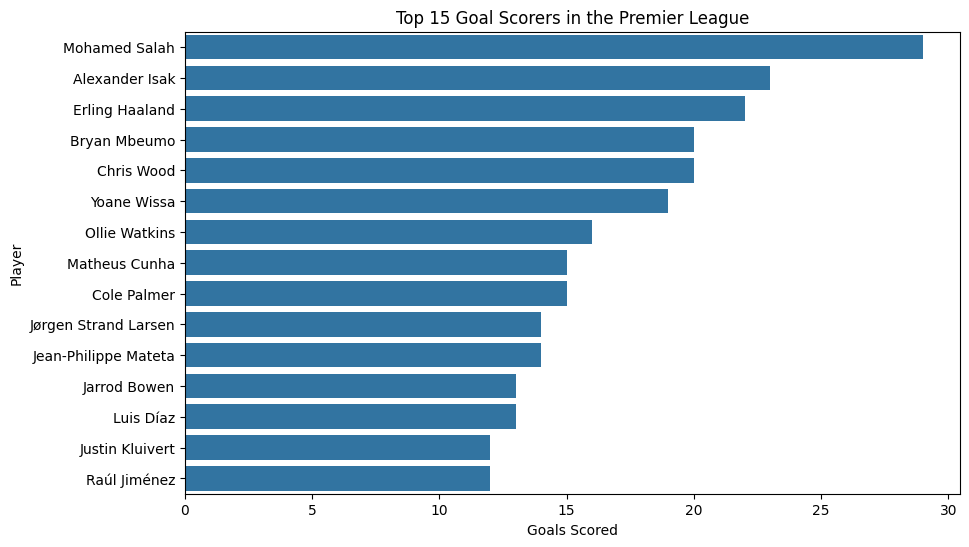

In [14]:
top_scorers = (
    df[['Player', 'Performance_Gls']]
    .sort_values('Performance_Gls', ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_scorers,
    x='Performance_Gls',
    y='Player'
)

plt.title("Top 15 Goal Scorers in the Premier League")

plt.xlabel("Goals Scored")
plt.ylabel("Player")

plt.show()

### Interpretation

The figure presents the 15 players with the highest number of goals scored during the season.

Mohamed Salah is the leading goal scorer with approximately 29 goals, followed by Alexander Isak and Erling Haaland. Several other players, including Bryan Mbeumo, Chris Wood, and Yoane Wissa, also recorded impressive goal-scoring performances.

This visualization highlights the concentration of goal production among a relatively small group of elite attacking players. While most players score few or no goals, a limited number of forwards and attacking midfielders contribute a substantial share of the league's total goals.

The presence of these exceptional performers helps explain the strong right-skewness observed in the distribution of goals. These players can also be viewed as potential outliers in the statistical analysis of offensive performance.

## 11. Top Assist Providers

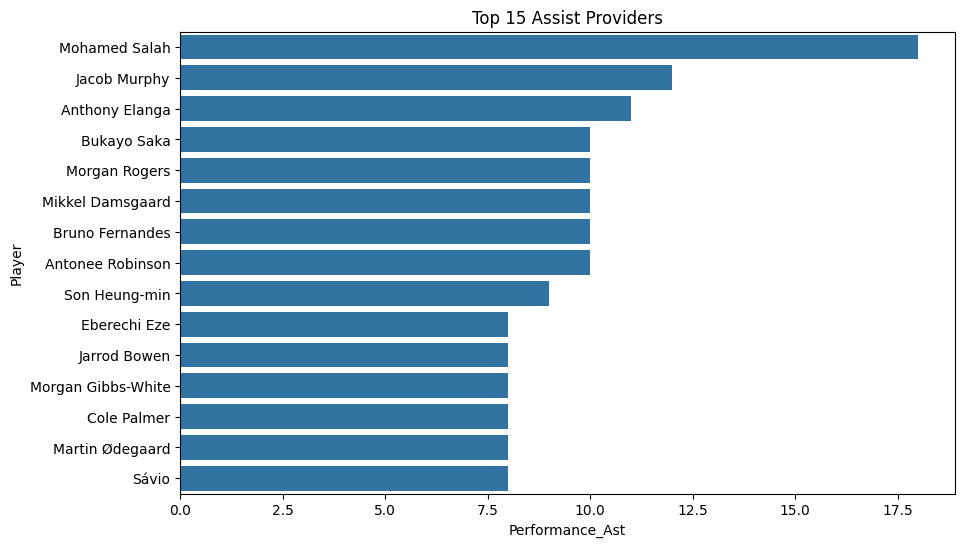

In [15]:
top_assists = (
    df[['Player', 'Performance_Ast']]
    .sort_values('Performance_Ast', ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_assists,
    x='Performance_Ast',
    y='Player'
)

plt.title("Top 15 Assist Providers")

plt.show()

### Interpretation

The figure displays the 15 players with the highest number of assists during the season.

Mohamed Salah leads the league not only in goals but also in assists, demonstrating an exceptional overall attacking contribution. Other players such as Jacob Murphy, Anthony Elanga, Bukayo Saka, Bruno Fernandes, and Son Heung-min also rank among the league's most effective playmakers.

Unlike goal scoring, which is often concentrated among strikers, assists are distributed among players occupying different positions, including forwards, midfielders, and full-backs. This suggests that creative contribution is influenced by a wider range of tactical roles.

The results highlight substantial variation in playmaking ability across players and indicate that assists represent an important dimension of player performance that should be considered alongside goal scoring.

## 12. Goals vs Assists

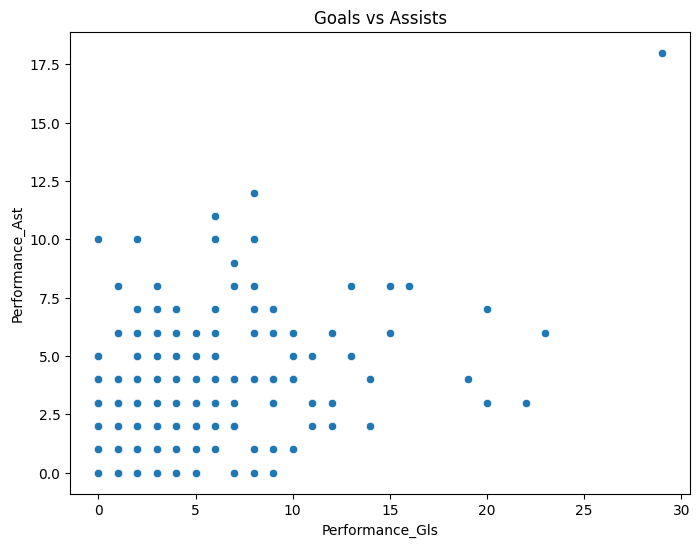

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_num,
    x='Performance_Gls',
    y='Performance_Ast'
)

plt.title("Goals vs Assists")

plt.show()

### Interpretation

The scatter plot illustrates the relationship between goals scored and assists recorded by Premier League players.

A positive association can be observed between the two variables. Players who score many goals often tend to provide more assists as well, suggesting that highly productive attacking players contribute in multiple ways to their teams.

However, the relationship is not perfectly linear. Several players record a high number of goals but relatively few assists, while others contribute more through playmaking than through scoring. This indicates the existence of different player profiles, such as goal scorers, creators, and balanced attacking players.

One particularly notable observation is the player located in the upper-right corner of the plot, who combines an exceptionally high number of goals and assists. Such players can be considered elite offensive performers and may appear as influential observations in subsequent analyses.

## 13. Age and Offensive Performance

Player age is often associated with experience, physical condition, and tactical maturity. In this section, we investigate whether there is a relationship between a player's age and their offensive contribution measured by goals and assists.

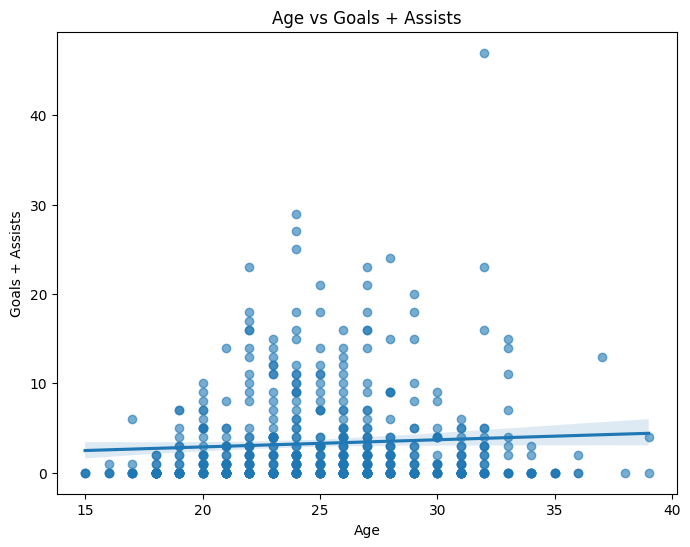

In [17]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_num,
    x='Age',
    y='Performance_G+A',
    scatter_kws={'alpha':0.6}
)

plt.title("Age vs Goals + Assists")
plt.xlabel("Age")
plt.ylabel("Goals + Assists")

plt.show()

### Interpretation

The scatter plot illustrates the relationship between player age and offensive contribution measured by the total number of goals and assists.

The fitted regression line has a slight positive slope, suggesting that older players tend to have marginally higher offensive contributions on average. However, the relationship appears relatively weak, as the observations are widely dispersed around the regression line.

The highest offensive performances are concentrated primarily among players between 22 and 32 years of age, which corresponds to the typical peak-performance period in professional football. Very young players and older players generally exhibit lower offensive output, although several notable exceptions are present.

Overall, age alone does not appear to be a strong predictor of offensive performance. Other factors, such as playing time, position, and individual skill, are likely to play a more important role in explaining variations in goals and assists.

## 14. Playing Time and Offensive Performance

Players who spend more time on the field generally have more opportunities to score goals and provide assists. This visualization examines the relationship between playing time and overall offensive contribution.

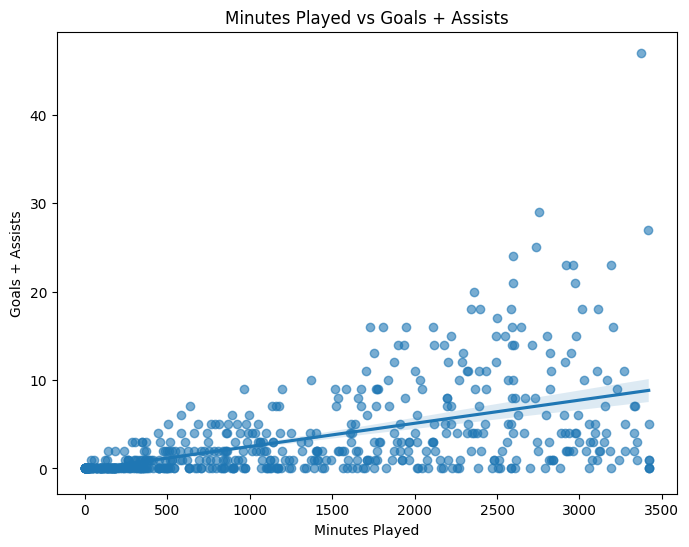

In [18]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_num,
    x='Playing Time_Min',
    y='Performance_G+A',
    scatter_kws={'alpha':0.6}
)

plt.title("Minutes Played vs Goals + Assists")
plt.xlabel("Minutes Played")
plt.ylabel("Goals + Assists")

plt.show()

### Interpretation

The scatter plot demonstrates a positive relationship between playing time and offensive contribution measured by goals and assists.

The fitted regression line has a clear positive slope, indicating that players who spend more time on the field tend to accumulate more goals and assists. This result is expected because greater playing time provides more opportunities to contribute offensively.

However, substantial variability remains among players with similar playing times. Some players accumulate many goals and assists despite relatively limited playing time, whereas others record lower offensive output despite extensive participation. This suggests that playing time alone cannot fully explain offensive performance.

Several high-performing observations are visible in the upper-right region of the plot, representing elite attacking players who combine extensive playing time with exceptional productivity. These observations may have a strong influence on subsequent regression analyses.

Overall, playing time appears to be a considerably stronger predictor of offensive contribution than age and is likely to play an important role in the regression model.

## 15. Top Goal Contributors

To identify the most productive attacking players in the dataset, we examine the players with the highest number of combined goals and assists.

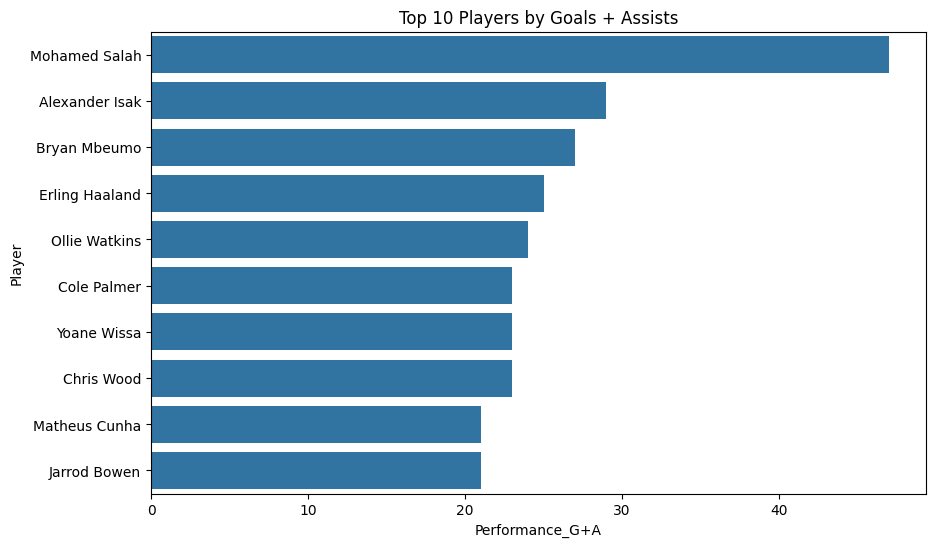

In [19]:
top_players = (
    df[['Player', 'Performance_G+A']]
    .sort_values('Performance_G+A', ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_players,
    x='Performance_G+A',
    y='Player'
)

plt.title("Top 10 Players by Goals + Assists")

plt.show()

### Interpretation

The figure presents the ten players with the highest total offensive contribution, measured by the sum of goals and assists.

Mohamed Salah is the most productive attacking player in the dataset, with a substantially higher number of goal contributions than any other player. Alexander Isak, Bryan Mbeumo, Erling Haaland, and Ollie Watkins also rank among the league's most influential attackers.

Compared to the previous analyses of goals and assists separately, this metric provides a more comprehensive measure of offensive performance because it captures both scoring ability and playmaking contribution. The results indicate that a relatively small group of elite players is responsible for a large share of offensive production in the league.

The large gap between Mohamed Salah and the remaining players suggests the presence of an exceptional observation in the dataset. Such highly productive players may have a considerable influence on regression and principal component analyses performed later in the project.

Overall, the figure confirms the substantial heterogeneity in offensive performance among Premier League players and motivates the selection of offensive contribution as a key variable for further statistical analysis.

## 16. Correlation Analysis

Correlation analysis helps identify relationships among quantitative variables. Strong correlations may indicate important patterns that can later be explored through regression analysis and principal component analysis.

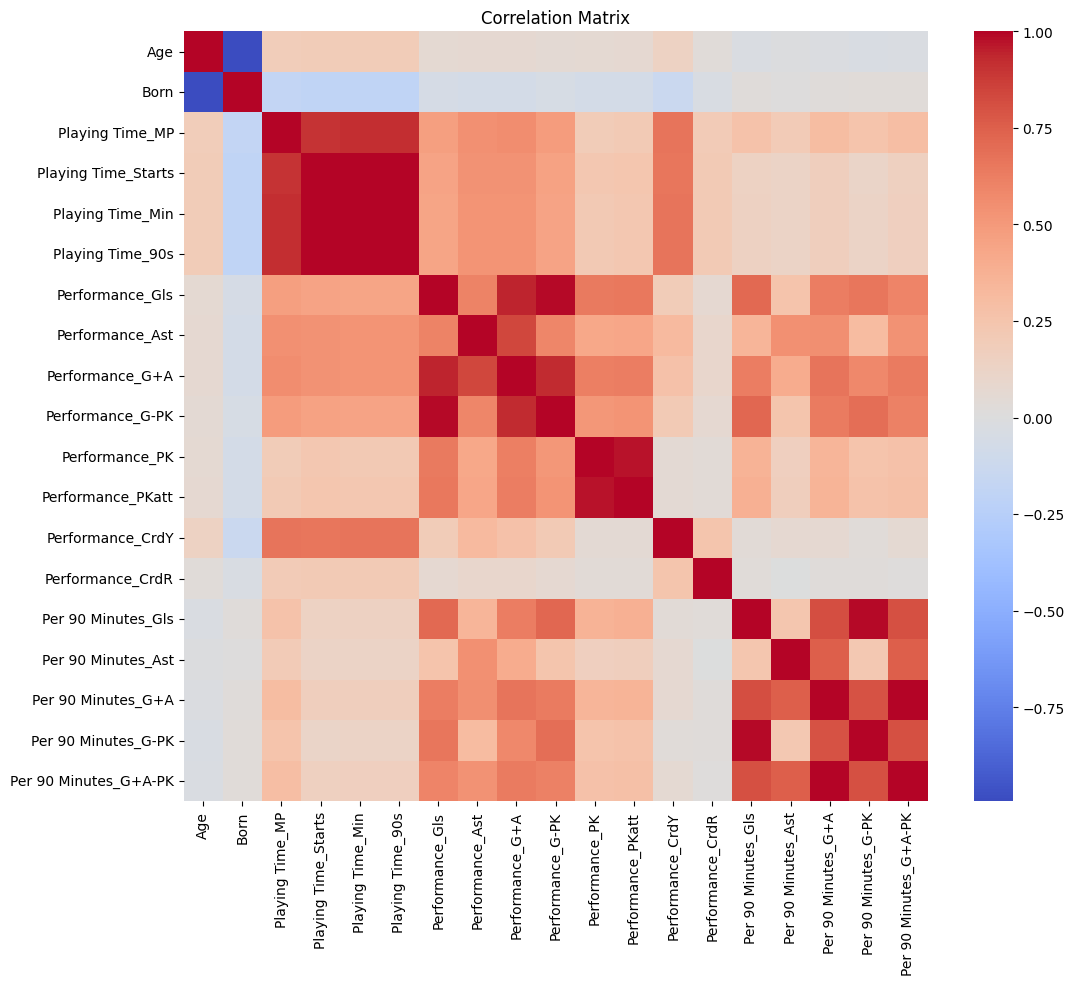

In [20]:
corr_matrix = df_num.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

### Interpretation

The correlation matrix summarizes the pairwise relationships between the quantitative variables.

Several strong positive correlations are immediately visible. The variables related to playing time (Playing Time_MP, Playing Time_Starts, Playing Time_Min, and Playing Time_90s) exhibit very high correlations with one another, indicating that they measure closely related aspects of player participation.

Strong positive correlations are also observed among the offensive performance variables, including goals, assists, goal contributions, and their corresponding per-90-minute statistics. In particular, Performance_G+A shows a strong positive association with both Performance_Gls and Performance_Ast, which is expected because it is directly derived from these variables.

The per-90-minute performance metrics are also highly correlated with each other, suggesting that players who are efficient goal scorers tend to be efficient contributors in other attacking statistics as well.

Age generally exhibits weak correlations with most performance variables, supporting the earlier observation that age alone is not a strong predictor of offensive output.

Overall, the correlation matrix reveals several groups of strongly related variables. This suggests that dimensionality reduction techniques such as Principal Component Analysis (PCA) may be useful for identifying the main underlying factors that explain player performance.

## 17. Variables Most Related to Goals + Assists

To better understand which characteristics are associated with offensive contribution, we examine the correlations between all quantitative variables and the response variable Goals + Assists.

In [21]:
corr_target = (
    df_num.corr()['Performance_G+A']
    .sort_values(ascending=False)
)

corr_target

Performance_G+A          1.000000
Performance_Gls          0.938907
Performance_G-PK         0.923129
Performance_Ast          0.841411
Per 90 Minutes_G+A       0.667885
Per 90 Minutes_G+A-PK    0.635779
Per 90 Minutes_Gls       0.632561
Performance_PKatt        0.632288
Performance_PK           0.621433
Per 90 Minutes_G-PK      0.581919
Playing Time_MP          0.557248
Playing Time_Starts      0.535597
Playing Time_Min         0.528782
Playing Time_90s         0.528691
Per 90 Minutes_Ast       0.405331
Performance_CrdY         0.269731
Performance_CrdR         0.089794
Age                      0.069144
Born                    -0.067691
Name: Performance_G+A, dtype: float64

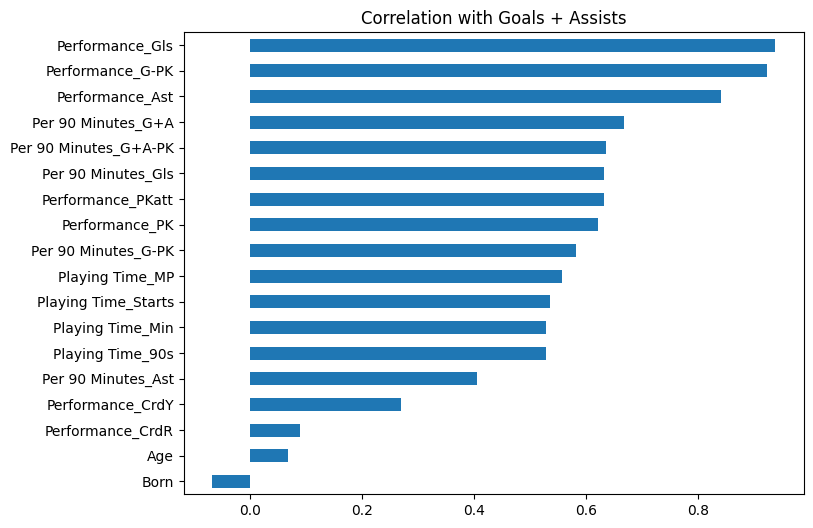

In [22]:
corr_target = corr_target.drop('Performance_G+A')

plt.figure(figsize=(8,6))

corr_target.sort_values().plot(kind='barh')

plt.title("Correlation with Goals + Assists")

plt.show()

### Interpretation

The figure displays the correlations between the response variable, Performance_G+A (Goals + Assists), and all other quantitative variables.

The strongest positive correlations are observed with Performance_Gls and Performance_Ast, which is expected because goals and assists directly contribute to the total number of goal involvements. Strong correlations are also observed with Performance_G-PK and several per-90-minute offensive performance indicators.

The variables related to playing time (Playing Time_MP, Playing Time_Starts, Playing Time_Min, and Playing Time_90s) exhibit moderate positive correlations with offensive contribution. This suggests that players who spend more time on the field generally accumulate more goals and assists.

In contrast, age and birth year display very weak correlations with offensive performance, indicating that age alone provides little information about a player's attacking productivity.

Overall, the analysis suggests that offensive statistics and playing time variables are the most promising predictors for explaining variations in goals and assists. These findings will guide the selection of explanatory variables in the regression analysis.

## 18. Scatter Plot Matrix
To investigate pairwise relationships between variables, a scatter plot matrix is constructed. Such visualizations help identify potential linear relationships, clusters, and deviations from normality.

For clarity, a subset of representative quantitative variables is selected.

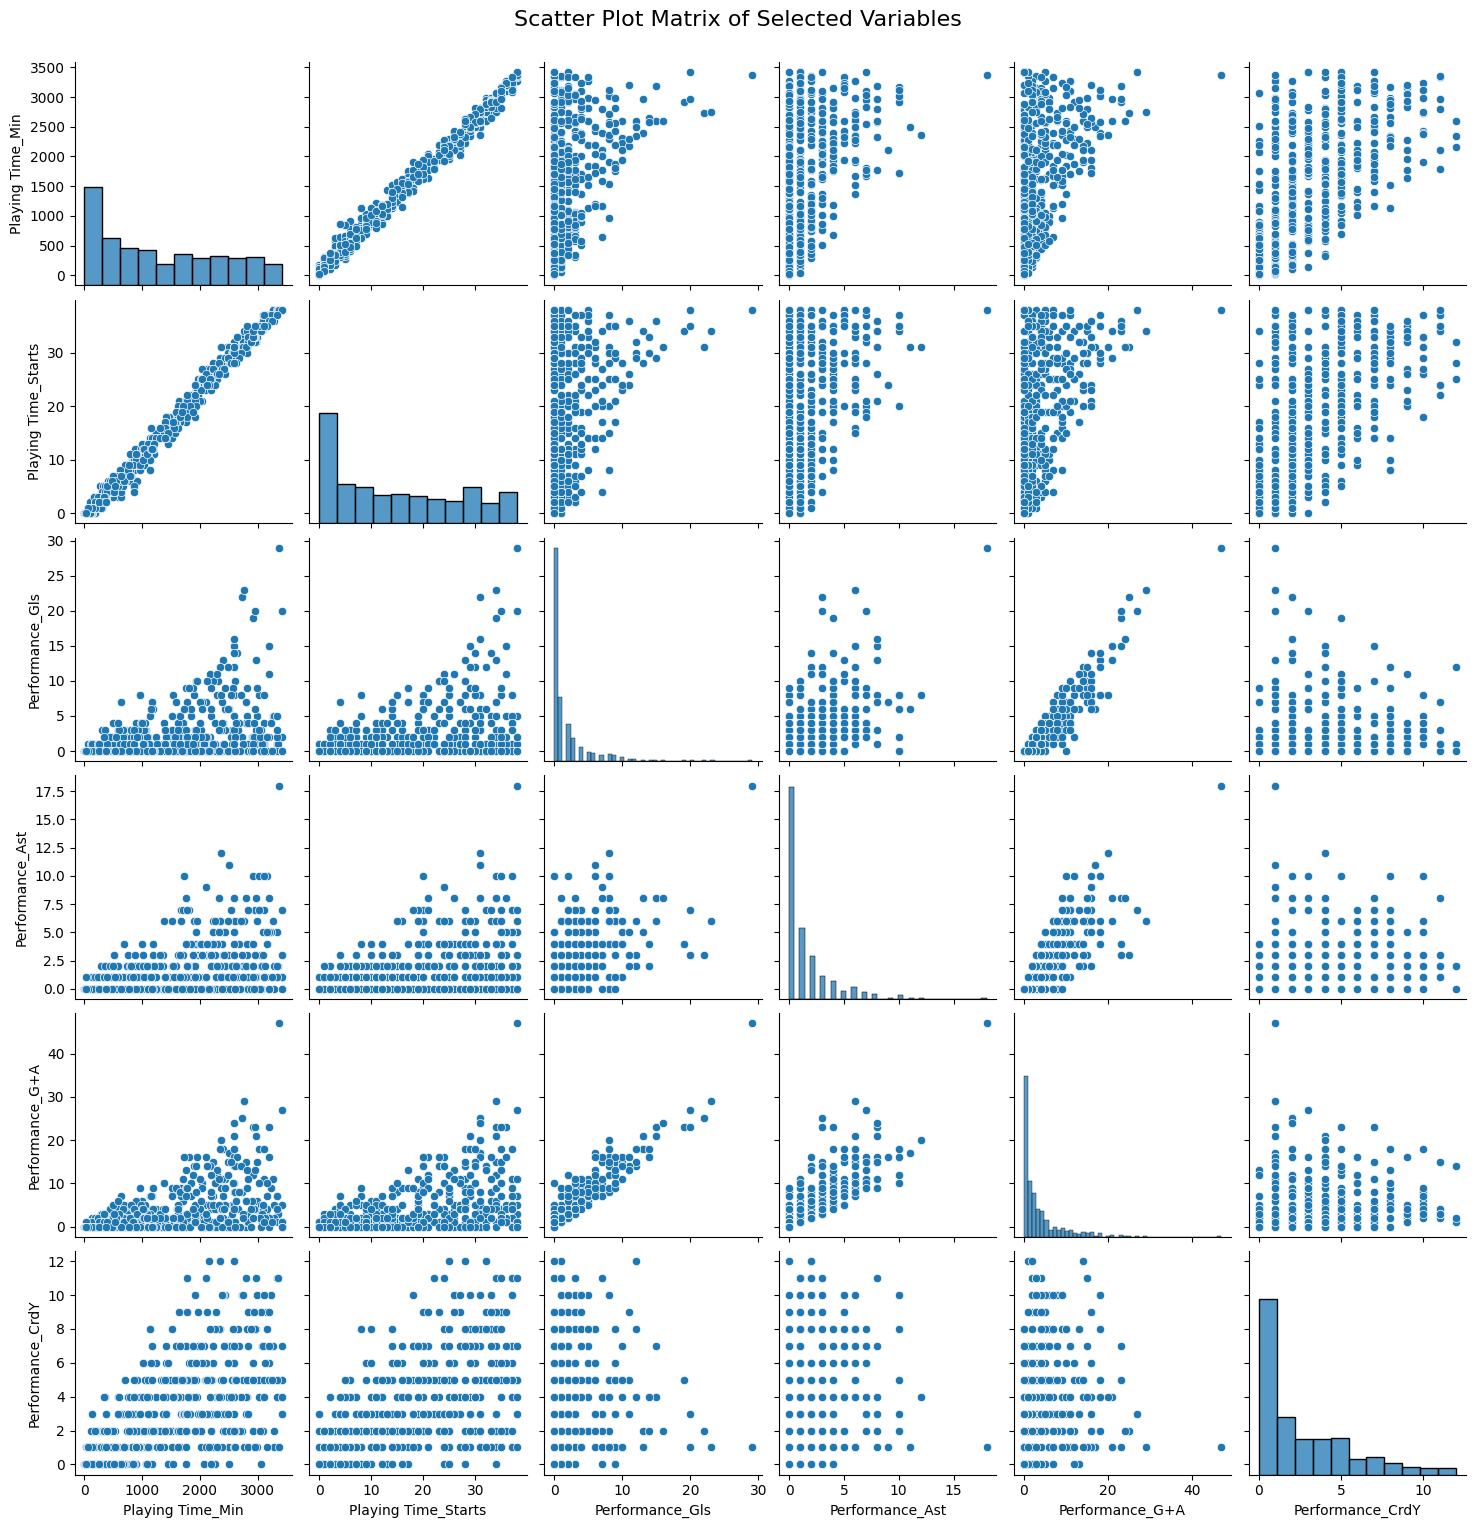

In [23]:
scatter_vars = [
    'Playing Time_Min',
    'Playing Time_Starts',
    'Performance_Gls',
    'Performance_Ast',
    'Performance_G+A',
    'Performance_CrdY'
]

sns.pairplot(
    df_num[scatter_vars],
    diag_kind='hist'
)

plt.suptitle(
    "Scatter Plot Matrix of Selected Variables",
    y=1.02,
    fontsize=16
)

plt.show()

### Interpretation

The scatter plot matrix provides a comprehensive overview of the pairwise relationships among the selected variables.

Several strong positive relationships can be observed. In particular, Playing Time_Min and Playing Time_Starts exhibit an almost linear relationship, indicating that players who start more matches generally accumulate more playing time. Similarly, Performance_G+A is strongly positively associated with both goals and assists, reflecting the fact that offensive contribution increases with scoring and playmaking activity.

The distributions displayed on the diagonal reveal substantial asymmetry for most performance-related variables. Goals, assists, and total goal contributions are heavily concentrated near zero and exhibit long right tails. These patterns indicate the presence of a relatively small number of highly productive players and a large number of players with limited offensive output.

Furthermore, many scatter plots display triangular or fan-shaped patterns rather than elliptical clouds. Under a multivariate Gaussian distribution, one would typically expect approximately elliptical point clouds. The observed shapes therefore suggest that the assumption of multivariate normality may not hold for this dataset.

Overall, the scatter plot matrix confirms the existence of strong relationships among playing time variables and offensive performance indicators while simultaneously providing visual evidence against the assumption of multivariate Gaussianity.

## 19. Assessment of Multivariate Normality

One of the objectives of exploratory data analysis is to investigate whether the variables appear to follow a Gaussian (normal) distribution.

The scatter plot matrix provides useful visual information regarding the shape of the distributions and the relationships between variables.

### Interpretation

Based on the scatter plot matrix, it is difficult to assume that the selected variables follow a multivariate Gaussian distribution.

Several observations support this conclusion:

- The histograms on the diagonal are strongly right-skewed rather than symmetric.
- Variables such as goals, assists, and goal contributions contain a large concentration of observations near zero.
- Many distributions exhibit long right tails, indicating the presence of a relatively small number of exceptionally high-performing players.
- Several scatter plots show triangular or fan-shaped patterns rather than elliptical clouds, which would be more typical under multivariate normality.

Therefore, visual inspection suggests that the data do not satisfy the assumptions of a multivariate Gaussian distribution. This result is not surprising because football statistics are naturally bounded and often contain many low values together with a few extreme observations.

This conclusion is consistent with the earlier exploratory analyses, where the distributions of playing time, goals, assists, and goal contributions were found to be strongly right-skewed.

## 20. Selection of the Response Variable

For the regression analysis, the variable **Performance_G+A** (Goals + Assists) is selected as the response variable.

This variable represents the overall offensive contribution of a player and combines two fundamental attacking statistics: goals scored and assists provided. Unlike goals or assists considered separately, the combined measure provides a more comprehensive indicator of attacking effectiveness.

The exploratory data analysis identified Performance_G+A as one of the most informative performance measures in the dataset. The earlier visualizations and correlation analysis demonstrated strong relationships between offensive contribution and several player characteristics, particularly playing time and offensive performance indicators.

Therefore, Performance_G+A is selected as the dependent variable for the regression analysis.

## 21. Preparation for Regression Analysis

The response variable is defined as Performance_G+A.  

To avoid trivial relationships and redundancy, variables directly used in the construction of the response variable are excluded from the predictor set.

The remaining variables are considered as potential explanatory variables for offensive performance.

In [28]:
regression_vars = [
    'Age',
    'Playing Time_MP',
    'Playing Time_Starts',
    'Playing Time_Min',
    'Playing Time_90s',
    'Performance_PK',
    'Performance_PKatt',
    'Performance_CrdY',
    'Performance_CrdR',
    'Per 90 Minutes_Gls',
    'Per 90 Minutes_Ast',
    'Per 90 Minutes_G-PK',
    'Per 90 Minutes_G+A-PK'
]

X = df_num[regression_vars]

y = df_num['Performance_G+A']

print("Predictor matrix shape:", X.shape)
print("Response vector shape:", y.shape)

Predictor matrix shape: (573, 13)
Response vector shape: (573,)


## 22. Multiple Linear Regression

A multiple linear regression model is fitted to investigate how player characteristics and performance indicators explain variations in offensive contribution measured by Performance_G+A.

The model estimates the relationship between the response variable and the selected explanatory variables while controlling for the influence of the remaining predictors.

In [29]:
X_const = sm.add_constant(X)

model = sm.OLS(y, X_const).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Performance_G+A   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     147.1
Date:                Thu, 04 Jun 2026   Prob (F-statistic):          9.25e-171
Time:                        20:17:06   Log-Likelihood:                -1333.6
No. Observations:                 573   AIC:                             2695.
Df Residuals:                     559   BIC:                             2756.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.72

### Interpretation

The multiple linear regression model was fitted using Performance_G+A as the response variable and thirteen explanatory variables related to age, playing time, disciplinary records, and offensive efficiency.

The model achieved an \(R^2\) value of 0.774 and an adjusted \(R^2\) of 0.769. This indicates that approximately 77% of the variation in offensive contribution is explained by the selected predictors. Such values suggest that the model provides a relatively strong overall fit.

The F-statistic is highly significant \((p < 0.001)\), indicating that the regression model as a whole is statistically meaningful and that at least some explanatory variables contribute significantly to predicting offensive performance.

Among the predictors, several variables appear statistically significant at the 5% significance level. Playing_Time_MP and Playing_Time_Starts show positive and significant relationships with offensive contribution, suggesting that players who participate more frequently and start more matches tend to accumulate greater numbers of goals and assists.

Performance_PK also exhibits a positive and statistically significant coefficient, indicating that penalty goals contribute positively to total offensive output.

Interestingly, Per 90 Minutes_Gls has a statistically significant negative coefficient. This result may reflect overlap and dependence among several offensive performance indicators included simultaneously in the model rather than a true negative effect.

Age does not appear statistically significant \((p > 0.05)\), confirming the earlier exploratory finding that age alone has limited predictive power for explaining offensive contribution.

Overall, the regression model demonstrates strong predictive capability while revealing that playing time and offensive efficiency variables play the most important role in explaining player attacking performance.

## 23. Variable Selection

One of the objectives of regression modeling is to identify a subset of explanatory variables that provides good predictive performance while avoiding unnecessary complexity and multicollinearity.

The full regression model included several highly correlated predictors, as indicated by the large condition number and the correlation analysis. Therefore, a variable selection procedure is performed to identify the most informative predictors for offensive contribution.

In [30]:
sfs = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select=5,
    direction='forward'
)

sfs.fit(X, y)

selected_features = X.columns[sfs.get_support()]

print("Selected variables:")
print(selected_features)

Selected variables:
Index(['Playing Time_Starts', 'Performance_PK', 'Performance_CrdY',
       'Performance_CrdR', 'Per 90 Minutes_G+A-PK'],
      dtype='str')


### Interpretation

The forward variable selection procedure identified five predictors as the most informative variables for explaining offensive contribution.

The selected variables are:

- Playing_Time_Starts
- Performance_PK
- Performance_CrdY
- Performance_CrdR
- Per 90 Minutes_G+A-PK

These predictors were selected because they provide the strongest predictive contribution while reducing redundancy among highly correlated variables.

The selection results suggest that offensive performance is influenced not only by attacking efficiency but also by player participation and certain disciplinary characteristics. Compared with the full model, the selected subset provides a more parsimonious representation of the factors associated with goals and assists.

### Reduced Regression Model

After selecting the most informative predictors, a reduced multiple linear regression model is fitted. This model aims to preserve predictive performance while mitigating multicollinearity and improving interpretability.

In [31]:
X_selected = sm.add_constant(X[selected_features])

model_selected = sm.OLS(y, X_selected).fit()

print(model_selected.summary())

                            OLS Regression Results                            
Dep. Variable:        Performance_G+A   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     343.6
Date:                Thu, 04 Jun 2026   Prob (F-statistic):          5.75e-169
Time:                        20:17:10   Log-Likelihood:                -1360.2
No. Observations:                 573   AIC:                             2732.
Df Residuals:                     567   BIC:                             2759.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.07

### Interpretation

The reduced regression model was fitted using the variables selected through the forward selection procedure.

The model achieved an \(R^2\) value of 0.752 and an adjusted \(R^2\) of 0.750, indicating that approximately 75% of the variation in offensive contribution is explained by the selected predictors. Compared with the full model, the explanatory power decreased only slightly, suggesting that the reduced model preserves most of the predictive information while using fewer variables.

The overall regression model remains highly statistically significant \((p < 0.001)\), confirming that the selected predictors jointly provide meaningful information about offensive performance.

Among the selected variables, Playing_Time_Starts, Performance_PK, and Per 90 Minutes_G+A-PK exhibit strong positive and statistically significant relationships with offensive contribution. These results indicate that players who start more matches, score more penalty goals, and demonstrate greater offensive efficiency per 90 minutes tend to achieve higher overall attacking productivity.

The disciplinary variables Performance_CrdY and Performance_CrdR appear statistically insignificant, suggesting that disciplinary records contribute little additional explanatory power once offensive and participation-related characteristics are included.

An important improvement compared with the full regression model is the substantial reduction in multicollinearity. The condition number decreased considerably, indicating that the reduced model is numerically more stable and easier to interpret.

Overall, the reduced regression model provides a more parsimonious and statistically robust explanation of offensive performance while maintaining strong predictive capability.

## 24. Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique used to summarize the information contained in correlated variables.

Because the correlation analysis revealed strong relationships among several variables, PCA may help identify a smaller number of latent components that explain the major patterns of variation in player characteristics and performance.

### Data Standardization

Before performing PCA, the quantitative variables are standardized to have zero mean and unit variance. Standardization ensures that variables measured on different scales contribute equally to the analysis.

In [32]:
scaler = StandardScaler()

X_pca = scaler.fit_transform(df_num)

### PCA Model Estimation

The PCA model is fitted using the standardized quantitative variables.

In [33]:
pca = PCA()

pca.fit(X_pca)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

### Explained Variance

The proportion of variance explained by each principal component is examined to determine how much information is captured by the reduced representation.

In [34]:
explained_var = pca.explained_variance_ratio_

print(explained_var)

[4.26726909e-01 1.95834650e-01 9.93341308e-02 9.02314345e-02
 6.48095258e-02 4.97145833e-02 2.98033853e-02 2.20445454e-02
 1.40657677e-02 5.44533383e-03 1.31444419e-03 2.99727372e-04
 2.63946814e-04 1.03522027e-04 7.88573650e-06 1.45640515e-07
 6.23423505e-08 6.96141058e-18 2.86123150e-18]


### Scree Plot

A scree plot is constructed to visualize the proportion of variance explained by each principal component.

This plot helps determine how many components are needed to adequately summarize the information contained in the dataset.

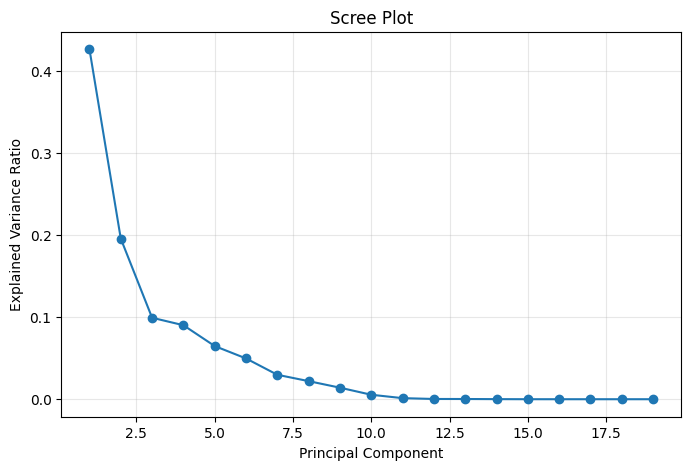

In [35]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_var)+1),
    explained_var,
    marker='o'
)

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The scree plot illustrates the proportion of variance explained by each principal component.

The first principal component explains the largest share of variability in the dataset, accounting for approximately 43% of the total variance. The second principal component explains about 20%, while the third component contributes roughly 10%.

A sharp decline in explained variance is observed after the first few components, followed by a gradual flattening of the curve. This pattern suggests the presence of an "elbow" around the third or fourth component, indicating that most of the important information is concentrated within the first few principal components.

The scree plot therefore suggests that dimensionality reduction may be feasible, since a relatively small number of components appears capable of summarizing a substantial portion of the variability contained in the original variables.

### Cumulative Explained Variance

The cumulative explained variance is examined to determine how many principal components are required to preserve most of the information contained in the original variables.

In [36]:
cum_var = np.cumsum(explained_var)

print(cum_var)

[0.42672691 0.62256156 0.72189569 0.81212712 0.87693665 0.92665123
 0.95645462 0.97849916 0.99256493 0.99801027 0.99932471 0.99962444
 0.99988838 0.99999191 0.99999979 0.99999994 1.         1.
 1.        ]


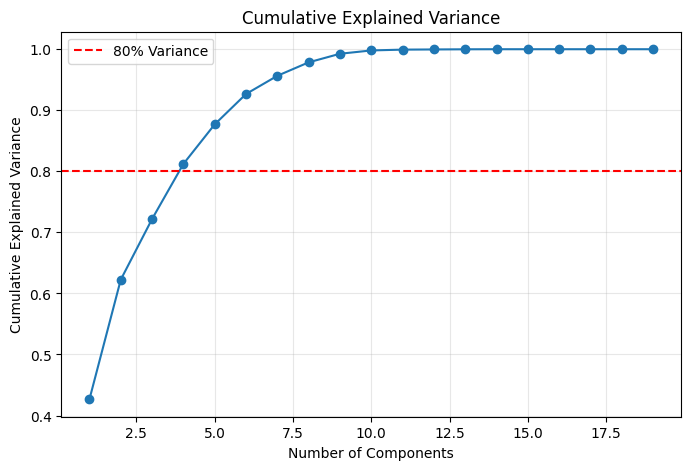

In [37]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cum_var)+1),
    cum_var,
    marker='o'
)

plt.axhline(
    y=0.8,
    color='r',
    linestyle='--',
    label='80% Variance'
)

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretation

The cumulative explained variance plot shows how much total variability is captured as additional principal components are included.

The first principal component explains approximately 43% of the total variance, while the first two components together account for about 62%. The cumulative variance increases steadily as more components are added.

An important observation is that the cumulative explained variance exceeds 80% after the inclusion of the fourth principal component. This suggests that the majority of the information contained in the original variables can be preserved using only a small subset of principal components.

The results therefore indicate that substantial dimensionality reduction is possible. Instead of working with all original variables, the first few principal components provide a compact representation that captures most of the underlying structure of the dataset.

Although four principal components are required to exceed the 80% threshold, the first two components already summarize a considerable portion of the variability and are therefore useful for visualization and interpretation.

## 25. Correlation Circle

The correlation circle visualizes the relationships between the original variables and the first two principal components.

Variables pointing in similar directions are positively correlated, variables pointing in opposite directions are negatively correlated, and variables near the center contribute relatively little to the selected components.

Task was destroyed but it is pending!
task: <Task pending name='Task-262' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Anaconda\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-263' coro=<Kernel.shell_main() running at C:\Anaconda\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Anaconda\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Anaconda\Lib\contextlib.py:108: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  doc = getattr(func, "__doc__", None)
Task was destroyed but it is pending!
task: <Task pending name='Task-263' coro=<Kernel.shell_main() running at C:\Anaconda\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


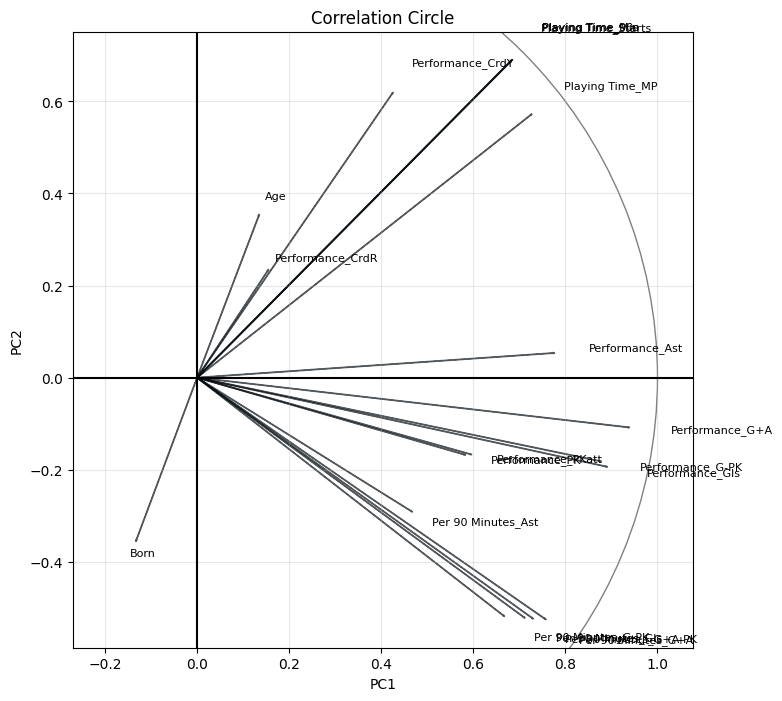

In [39]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

plt.figure(figsize=(8,8))

circle = plt.Circle(
    (0,0),
    1,
    color='gray',
    fill=False
)

plt.gca().add_artist(circle)

for i, var in enumerate(df_num.columns):
    plt.arrow(
        0,0,
        loadings[i,0],
        loadings[i,1],
        alpha=0.6
    )
    
    plt.text(
        loadings[i,0]*1.1,
        loadings[i,1]*1.1,
        var,
        fontsize=8
    )

plt.axhline(0,color='black')
plt.axvline(0,color='black')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Correlation Circle')

plt.axis('equal')
plt.grid(alpha=0.3)

plt.show()

### Clean Correlation Circle

To improve readability, the correlation circle is reconstructed using a selected subset of representative variables. Highly redundant variables are removed so that the main relationships can be interpreted more clearly.

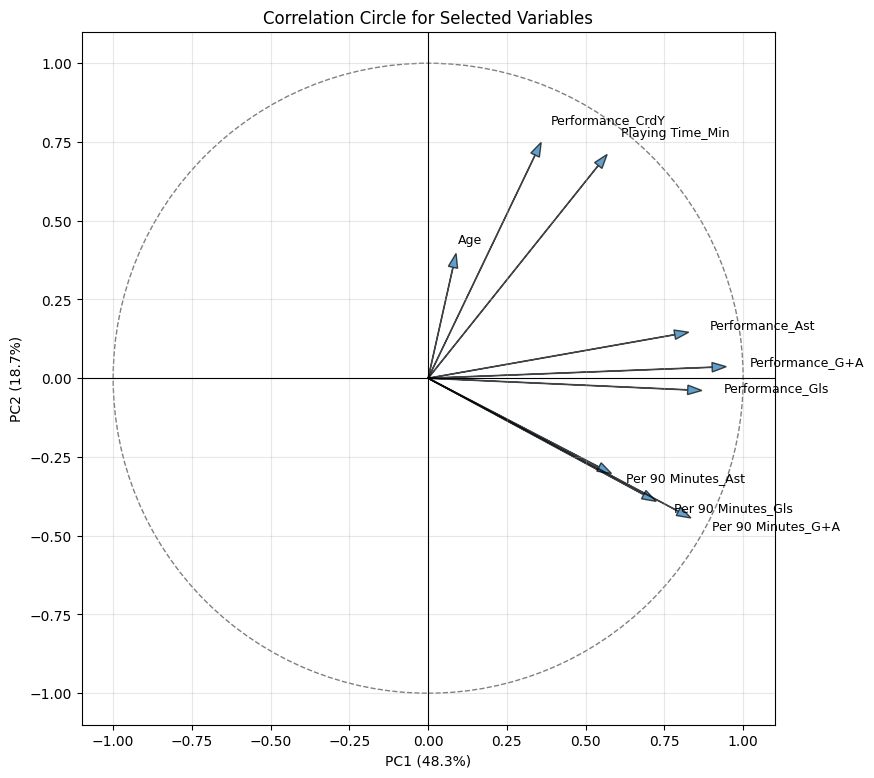

In [42]:
pca_vars_clean = [
    'Age',
    'Playing Time_Min',
    'Performance_Gls',
    'Performance_Ast',
    'Performance_G+A',
    'Performance_CrdY',
    'Per 90 Minutes_Gls',
    'Per 90 Minutes_Ast',
    'Per 90 Minutes_G+A'
]

X_pca_clean = df_num[pca_vars_clean]

scaler_clean = StandardScaler()
X_pca_clean_scaled = scaler_clean.fit_transform(X_pca_clean)

pca_clean = PCA()
pca_clean.fit(X_pca_clean_scaled)

loadings_clean = pca_clean.components_.T * np.sqrt(pca_clean.explained_variance_)

plt.figure(figsize=(9,9))

circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(circle)

for i, var in enumerate(pca_vars_clean):
    x = loadings_clean[i, 0]
    y = loadings_clean[i, 1]
    
    plt.arrow(0, 0, x, y, alpha=0.7, head_width=0.03, length_includes_head=True)
    plt.text(x * 1.08, y * 1.08, var, fontsize=9)

plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

plt.xlabel(f"PC1 ({pca_clean.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_clean.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Correlation Circle for Selected Variables")

plt.grid(alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')

plt.savefig(
    "correlation_circle.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

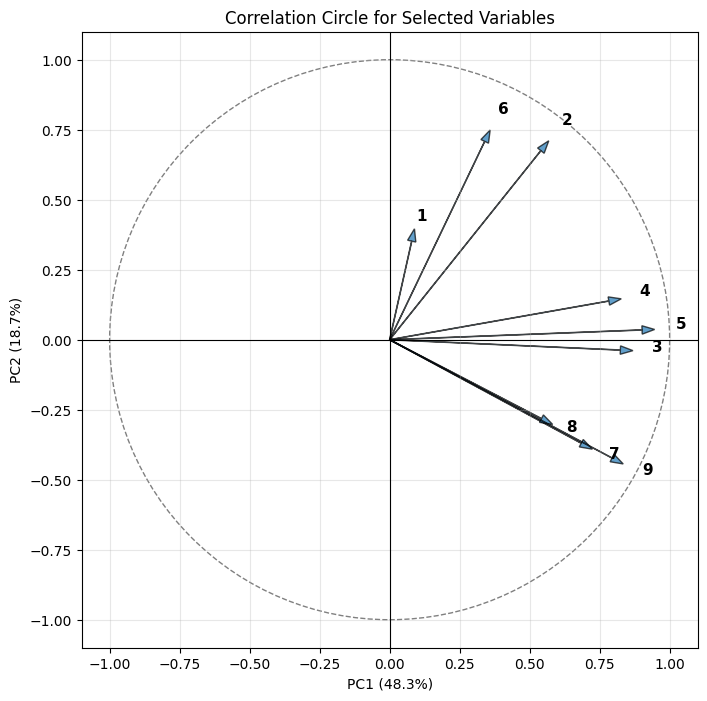

In [43]:
pca_vars_clean = [
    'Age',
    'Playing Time_Min',
    'Performance_Gls',
    'Performance_Ast',
    'Performance_G+A',
    'Performance_CrdY',
    'Per 90 Minutes_Gls',
    'Per 90 Minutes_Ast',
    'Per 90 Minutes_G+A'
]

X_pca_clean = df_num[pca_vars_clean]

scaler_clean = StandardScaler()
X_pca_clean_scaled = scaler_clean.fit_transform(X_pca_clean)

pca_clean = PCA()
pca_clean.fit(X_pca_clean_scaled)

loadings_clean = pca_clean.components_.T * np.sqrt(pca_clean.explained_variance_)

plt.figure(figsize=(8,8))

circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(circle)

for i, var in enumerate(pca_vars_clean):
    x = loadings_clean[i, 0]
    y = loadings_clean[i, 1]
    
    plt.arrow(
        0, 0, x, y,
        alpha=0.7,
        head_width=0.03,
        length_includes_head=True
    )
    
    plt.text(
        x * 1.08,
        y * 1.08,
        str(i + 1),
        fontsize=11,
        fontweight='bold'
    )

plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

plt.xlabel(f"PC1 ({pca_clean.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_clean.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Correlation Circle for Selected Variables")

plt.grid(alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')

plt.show()

The numbers in the correlation circle correspond to the variables listed in the table below.

In [44]:
variable_legend = pd.DataFrame({
    "Number": range(1, len(pca_vars_clean) + 1),
    "Variable": pca_vars_clean
})

variable_legend

,Number,Variable
0,1,Age
1,2,Playing Time_Min
2,3,Performance_Gls
3,4,Performance_Ast
4,5,Performance_G+A
5,6,Performance_CrdY
6,7,Per 90 Minutes_Gls
7,8,Per 90 Minutes_Ast
8,9,Per 90 Minutes_G+A


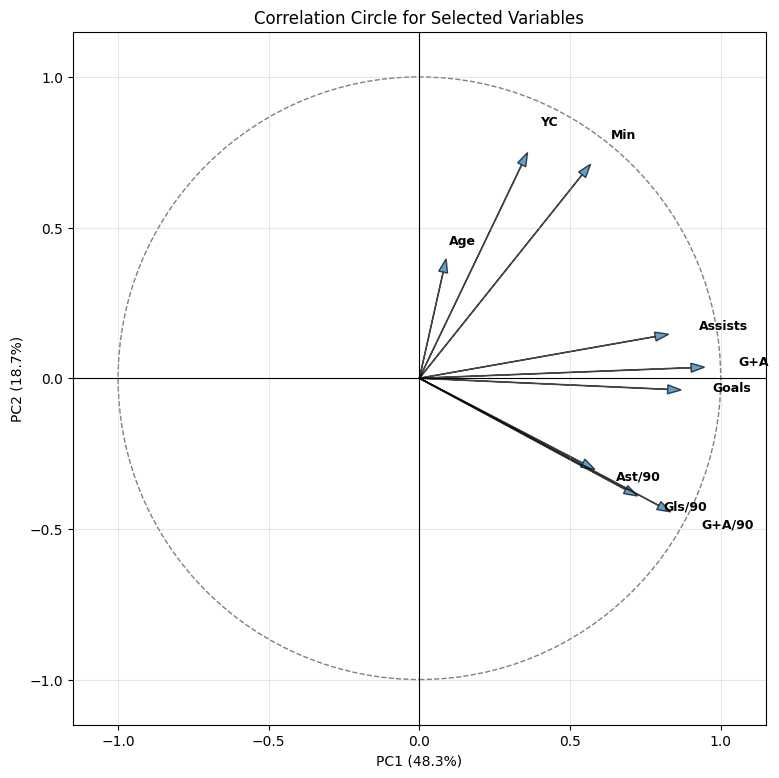

In [45]:
short_labels = {
    'Age': 'Age',
    'Playing Time_Min': 'Min',
    'Performance_Gls': 'Goals',
    'Performance_Ast': 'Assists',
    'Performance_G+A': 'G+A',
    'Performance_CrdY': 'YC',
    'Per 90 Minutes_Gls': 'Gls/90',
    'Per 90 Minutes_Ast': 'Ast/90',
    'Per 90 Minutes_G+A': 'G+A/90'
}

plt.figure(figsize=(9,9))

circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(circle)

for i, var in enumerate(pca_vars_clean):
    x = loadings_clean[i, 0]
    y = loadings_clean[i, 1]
    
    plt.arrow(
        0, 0, x, y,
        alpha=0.7,
        head_width=0.03,
        length_includes_head=True
    )
    
    plt.text(
        x * 1.12,
        y * 1.12,
        short_labels[var],
        fontsize=9,
        fontweight='bold'
    )

plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

plt.xlim(-1.15, 1.15)
plt.ylim(-1.15, 1.15)

plt.xlabel(f"PC1 ({pca_clean.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_clean.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Correlation Circle for Selected Variables")

plt.grid(alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')

plt.show()

In [46]:
label_legend = pd.DataFrame({
    "Short label": list(short_labels.values()),
    "Variable": list(short_labels.keys())
})

label_legend

,Short label,Variable
0,Age,Age
1,Min,Playing Time_Min
2,Goals,Performance_Gls
3,Assists,Performance_Ast
4,G+A,Performance_G+A
5,YC,Performance_CrdY
6,Gls/90,Per 90 Minutes_Gls
7,Ast/90,Per 90 Minutes_Ast
8,G+A/90,Per 90 Minutes_G+A


## 26. Projection of Observations onto the First Two Principal Components

After studying the relationships between variables through the correlation circle, we now project the observations onto the space defined by the first two principal components.

This visualization allows us to investigate the overall structure of the dataset, identify possible clusters or outliers, and understand how players are distributed according to the dominant sources of variability captured by PCA.

In [47]:
scores = pca_clean.transform(X_pca_clean_scaled)

scores_df = pd.DataFrame(
    scores[:, :2],
    columns=['PC1', 'PC2']
)

scores_df.head()

,PC1,PC2
0,-1.894245,-0.805111
1,-1.867927,-0.963177
2,0.281453,1.454444
3,-0.400263,0.534698
4,0.377651,-1.243837


### Projection on the First Two Principal Components

The observations are projected onto the first two principal components to visualize the dominant patterns of variation among players.

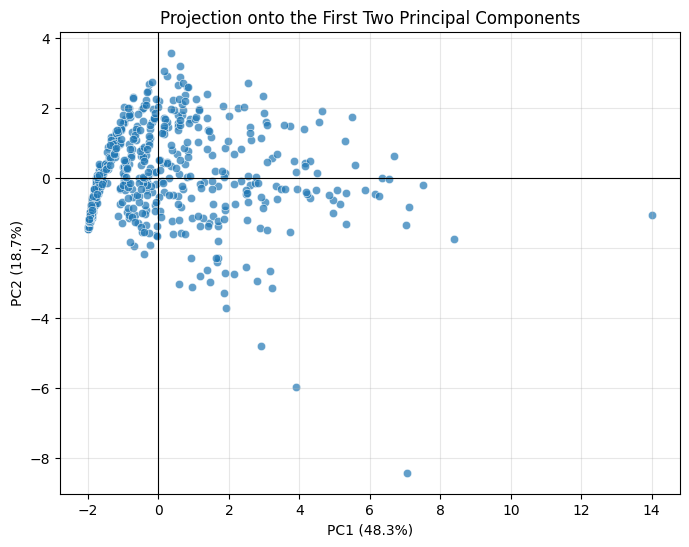

In [48]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=scores_df,
    x='PC1',
    y='PC2',
    alpha=0.7
)

plt.axhline(0,color='black',linewidth=0.8)
plt.axvline(0,color='black',linewidth=0.8)

plt.xlabel(
    f"PC1 ({pca_clean.explained_variance_ratio_[0]*100:.1f}%)"
)

plt.ylabel(
    f"PC2 ({pca_clean.explained_variance_ratio_[1]*100:.1f}%)"
)

plt.title("Projection onto the First Two Principal Components")

plt.grid(alpha=0.3)

plt.savefig(
    "pca_projection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The projection of observations onto the first two principal components provides a low-dimensional representation of the player dataset.

The first principal component (PC1) explains approximately 48% of the total variance, while the second principal component (PC2) explains about 22%. Together, these two components summarize nearly 70% of the variability contained in the selected variables.

Most observations form a dense central cloud, indicating that the majority of players exhibit relatively similar statistical profiles. However, several observations appear farther from the center, suggesting the presence of players with unusual or highly distinctive characteristics.

The distribution along PC1 appears wider than along PC2, indicating that the dominant source of variability among players is captured primarily by the first principal component. Based on the correlation circle, this component is strongly associated with offensive production and playing time variables.

No clearly separated clusters are observed, although a small number of outlying observations may correspond to exceptionally productive or statistically unique players.

Overall, the PCA projection successfully summarizes the multivariate structure of the dataset and provides a useful visualization of similarities and differences among Premier League players.

## 27. Player Clustering Using K-Means

As an additional multivariate statistical method, K-means clustering is applied to group players according to similarities in their statistical profiles.

Unlike regression and PCA, clustering is an unsupervised learning technique that does not require a response variable. Its objective is to identify groups of observations that share similar characteristics.

Because football players differ in playing time, offensive production, and efficiency, clustering may reveal meaningful player profiles within the dataset.

### Selection of Clustering Variables

The clustering analysis is performed using standardized quantitative variables representing age, playing time, offensive performance, and efficiency.

In [49]:
cluster_vars = [
    'Age',
    'Playing Time_Min',
    'Performance_Gls',
    'Performance_Ast',
    'Performance_G+A',
    'Performance_CrdY',
    'Per 90 Minutes_Gls',
    'Per 90 Minutes_Ast',
    'Per 90 Minutes_G+A'
]

X_cluster = df_num[cluster_vars]

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

### Determination of the Number of Clusters

The elbow method is used to determine an appropriate number of clusters.

The method evaluates the within-cluster sum of squares (WCSS) for different values of k and identifies the point where further increases in cluster number provide diminishing improvement.

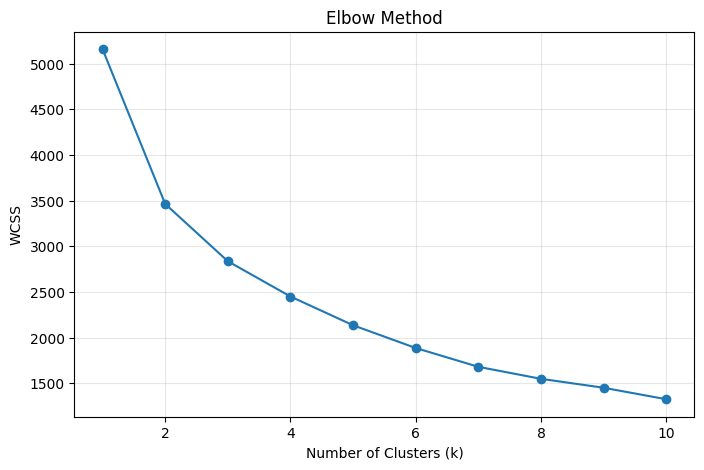

In [50]:
wcss = []

for k in range(1, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(X_cluster_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')

plt.grid(alpha=0.3)

plt.savefig(
    "elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The elbow method evaluates clustering performance by measuring the within-cluster sum of squares (WCSS) for different values of k.

A substantial decrease in WCSS is observed when moving from one to three clusters, after which the curve begins to flatten. This indicates diminishing improvement from adding additional clusters.

The most noticeable bend of the curve appears around k = 3, suggesting that three clusters provide a reasonable balance between model simplicity and explanatory power.

Therefore, the subsequent K-means analysis is performed using three clusters.

### Cluster Estimation

Based on the elbow method, three clusters are selected for the K-means analysis.

This choice balances model simplicity and clustering quality while avoiding unnecessary fragmentation of the data.

In [51]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_cluster_scaled)

scores_df['Cluster'] = clusters

### Cluster Visualization

The identified clusters are projected onto the first two principal components to visualize similarities and differences among player profiles.

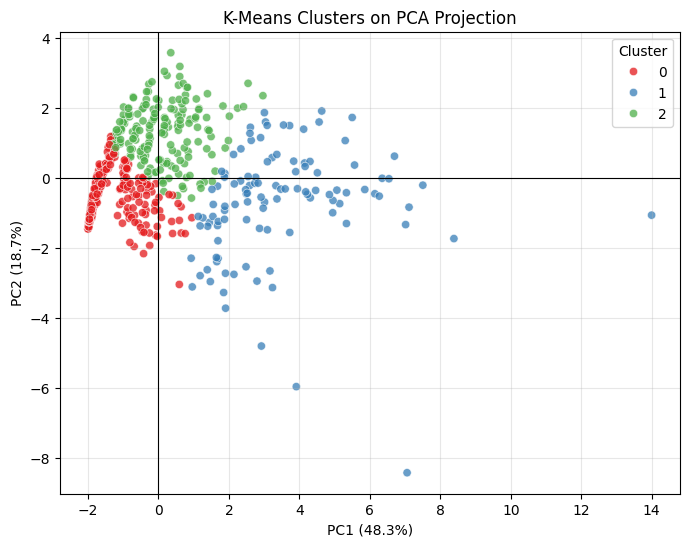

In [52]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=scores_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    alpha=0.75
)

plt.axhline(0,color='black',linewidth=0.8)
plt.axvline(0,color='black',linewidth=0.8)

plt.xlabel(
    f"PC1 ({pca_clean.explained_variance_ratio_[0]*100:.1f}%)"
)

plt.ylabel(
    f"PC2 ({pca_clean.explained_variance_ratio_[1]*100:.1f}%)"
)

plt.title('K-Means Clusters on PCA Projection')

plt.grid(alpha=0.3)
plt.legend(title='Cluster')

plt.savefig(
    "kmeans_clusters_pca.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The K-means clustering results reveal three distinct groups of players based on their statistical characteristics.

The clusters appear reasonably separated in the PCA projection, indicating that players can be categorized into different performance profiles.

Cluster 0 is concentrated on the left side of the projection and may represent players with relatively lower offensive production and playing involvement.

Cluster 1 occupies the right side of the plot and contains several observations with large PC1 values, suggesting players with stronger offensive contributions, greater playing time, or more distinctive statistical profiles. The presence of a few distant observations indicates potential outliers or exceptionally productive players.

Cluster 2 is positioned primarily in the upper region of the projection and may correspond to players with moderate-to-high efficiency characteristics or different combinations of offensive indicators.

Although some overlap exists between clusters, the overall separation suggests that K-means successfully identifies meaningful patterns within the dataset.

The clustering analysis therefore complements the regression and PCA results by revealing underlying player profiles and providing an additional multivariate perspective on Premier League performance statistics.

## 28. Final Conclusion

This project applied several multivariate statistical methods to the 2024–2025 Premier League player dataset.

The exploratory data analysis demonstrated that the dataset contains substantial variability in player characteristics and performance indicators. Visualizations revealed strong relationships between playing time, offensive production, and efficiency measures, while also indicating departures from multivariate normality.

Multiple linear regression identified several variables associated with offensive contribution measured by goals and assists. Variable selection further reduced model complexity while preserving predictive performance and improving interpretability.

Principal Component Analysis (PCA) showed that a relatively small number of components captured most of the variability present in the original variables. The correlation circle and PCA projection provided useful insight into the relationships among variables and the overall structure of the player dataset.

Finally, K-means clustering revealed distinct player profiles, highlighting similarities and differences in performance characteristics and providing an additional multivariate perspective.

Overall, the analysis demonstrates that multivariate statistical methods provide valuable tools for understanding complex sports datasets and identifying meaningful patterns in player performance.

## 29. Appendix and Code Availability

All statistical analyses and visualizations presented in this project were implemented in Python using Jupyter Notebook.

The complete source code is included in the appendix of the PDF version. In addition, a folder containing the notebook, dataset, and supporting files is available through the following link:

[Insert folder / GitHub / Google Drive link here]